In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [2]:

def mean_field_eom(t, y, Omega, beta, omega):
    phi, z = y

    # Driving phase
    phi0 = omega * t

    # Avoid singularities near |z| = 1
    eps = 1e-9
    z = np.clip(z, -1 + eps, 1 - eps)

    sqrt = np.sqrt(1 - z**2)
    delta = phi + phi0

    dz_dt = -Omega * sqrt * np.sin(delta)
    dphi_dt = -2* beta * z - Omega * z / sqrt * np.cos(delta)

    return [dphi_dt, dz_dt]

def poincare_section(phi_init, z_init, Omega, beta, omega, n_periods):
    """
    Compute Poincaré section sampled at integer multiples of the drive period.
    """
    T = 2 * np.pi / omega

    phi = phi_init
    z = z_init

    phi_points = []
    z_points = []

    for _ in range(n_periods):
        sol = solve_ivp(
            mean_field_eom,
            t_span=(0, T),
            y0=[phi, z],
            args=(Omega, beta, omega),
            rtol=1e-5,
            atol=1e-7
        )

        # Update state at end of one period
        phi, z = sol.y[0, -1], sol.y[1, -1]

        # Wrap phase
        phi = np.mod(phi, 2 * np.pi)

        phi_points.append(phi)
        z_points.append(z)

    return np.array(phi_points), np.array(z_points)


In [15]:
# Parameters
Omega = 1.0
beta = 1
omega = 1

# Initial condition
phi0 = 0
z0 = 0

# Compute Poincaré section
phi_pts, z_pts = poincare_section(
    phi0, z0,
    Omega, beta, omega,
    n_periods=2000
)

# Plot
plt.figure(figsize=(6, 4))
plt.scatter(phi_pts, z_pts, s=1)
plt.xlabel(r"$\phi$")
plt.ylabel(r"$z$")
plt.title("Poincaré section (mean-field dynamics)")
plt.show()


KeyboardInterrupt: 

In [19]:
# Parameters
Omega = 1.0
beta = 10
omega = 10
phi_total = []
z_total = []
plt.figure(figsize=(6, 4))

for phi0 in np.linspace(0, 2*np.pi, 8, endpoint=False):
    for z0 in np.linspace(-0.8, 0.8, 9):
        phi_pts, z_pts = poincare_section(
            phi0, z0,
            Omega, beta, omega,
            n_periods=1000
        )
        phi_total.append(phi_pts)
        z_total.append(z_pts)
        print(f"phi/pi = {phi0/np.pi}, z = {z0} calculated")

phi_total = np.array(phi_total)
z_total = np.array(z_total)

phi/pi = 0.0, z = -0.8 calculated
phi/pi = 0.0, z = -0.6000000000000001 calculated
phi/pi = 0.0, z = -0.4 calculated
phi/pi = 0.0, z = -0.19999999999999996 calculated
phi/pi = 0.0, z = 0.0 calculated
phi/pi = 0.0, z = 0.19999999999999996 calculated
phi/pi = 0.0, z = 0.40000000000000013 calculated
phi/pi = 0.0, z = 0.6000000000000001 calculated
phi/pi = 0.0, z = 0.8 calculated
phi/pi = 0.25, z = -0.8 calculated
phi/pi = 0.25, z = -0.6000000000000001 calculated
phi/pi = 0.25, z = -0.4 calculated
phi/pi = 0.25, z = -0.19999999999999996 calculated
phi/pi = 0.25, z = 0.0 calculated
phi/pi = 0.25, z = 0.19999999999999996 calculated
phi/pi = 0.25, z = 0.40000000000000013 calculated
phi/pi = 0.25, z = 0.6000000000000001 calculated
phi/pi = 0.25, z = 0.8 calculated
phi/pi = 0.5, z = -0.8 calculated
phi/pi = 0.5, z = -0.6000000000000001 calculated
phi/pi = 0.5, z = -0.4 calculated
phi/pi = 0.5, z = -0.19999999999999996 calculated
phi/pi = 0.5, z = 0.0 calculated
phi/pi = 0.5, z = 0.1999999999999

<Figure size 600x400 with 0 Axes>

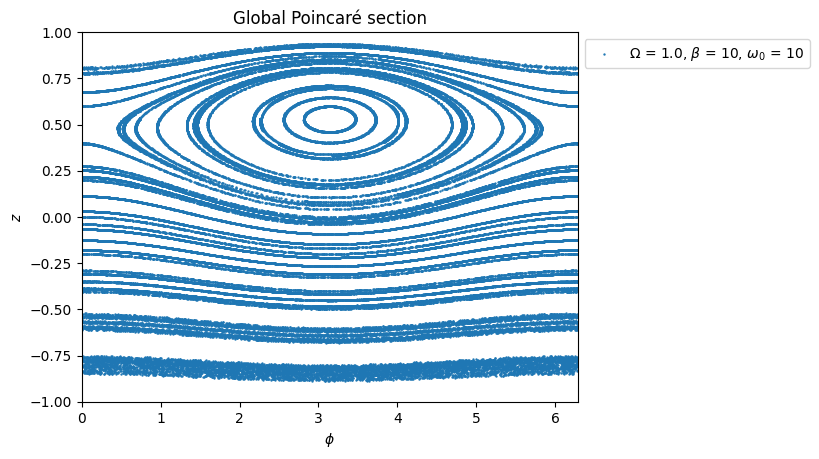

In [20]:
plt.scatter(phi_total, z_total, s=0.5, label = f"$\Omega$ = {Omega}, $\\beta$ = {beta}, $\omega_0$ = {omega}") 
plt.xlim(0, 2*np.pi)
plt.ylim(-1, 1)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.xlabel(r"$\phi$")
plt.ylabel(r"$z$")
plt.title("Global Poincaré section")
plt.show()


In [28]:
np.arange(11)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])